# SVNIT Department of Artificial Intelligence
## Subject: Machine Learning (AI301)
### Assignment 5: Gradient Descent Optimization, Regularization, Polynomial Regression, and Classification

---

**Student Name:** Jeetu Mehra  
**Roll Number:** U24AI032  
**Semester:** B.Tech Artificial Intelligence (4th Semester)  
**Institution:** Sardar Vallabhbhai National Institute of Technology (SVNIT), Surat  

---

### Aim:
To implement and rigorously analyze foundational machine learning optimization algorithms, model complexity behaviors, regularized linear regression techniques, binary logistic classification, and multiclass multinomial (Softmax) classification across synthetic and real-world benchmark datasets.

### Objectives & Problem Statements:
1. **Question 1:** Generate synthetic linear data $X = 2 \cdot \text{rand}(100, 1)$ and $y = 4 + 3X + \text{randn}(100, 1)$. Implement **Batch Gradient Descent (BGD)** from scratch ($\eta = 0.1$, 1000 iterations, random initial $\theta$). Plot MSE vs. iteration number and report the final converged parameter values $\theta$.
2. **Question 2:** Implement **Stochastic Gradient Descent (SGD)** from scratch on the same data (one random sample per step, learning schedule $\eta(t) = \frac{t_0}{t + t_1}$ with $t_0=5, t_1=50$, 50 epochs). Overlay its MSE trajectory against Batch GD on a single plot and report the total number of parameter updates performed by each method.
3. **Question 3:** Implement **Mini-batch Gradient Descent (MBGD)** ($\text{batch\_size}=20$, 50 epochs). Report the final parameter estimates $\theta$ for all three GD variants and the number of epochs each algorithm required to achieve $\text{MSE} < 1.0$ in a unified comparative table.
4. **Question 4:** Generate non-linear quadratic data $y = 0.5 X^2 + X + 2 + \epsilon$ for $X \in [-3, 3]$. Fit polynomial regression models at degrees 1, 2, and 300 using `PolynomialFeatures` and `LinearRegression`. Plot all three fitted curves against the training data. Generate diagnostic **learning curves** (Train/Validation RMSE vs. training-set size) for degree 1 (underfitting / high bias) and degree 300 (overfitting / high variance).
5. **Question 5:** On the **UCI Wine Quality (Red Wine)** dataset (`winequality-red.csv`), fit **Ridge**, **Lasso**, and **ElasticNet** regression models predicting wine quality across regularization strengths $\alpha \in \{0.001, 0.01, 0.1, 1, 10\}$. Report Test RMSE for every $(\text{model}, \alpha)$ combination in a structured table. Plot Lasso coefficient paths vs. $\alpha$ for all 11 physicochemical features and identify which feature shrinks to zero first.
6. **Question 6:** Binarize wine quality into **Good** ($\ge 7$) vs. **Not Good** ($< 7$). Fit a `LogisticRegression` binary classifier on an 80/20 train-test split. Evaluate and report Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC.
7. **Question 7:** On the **Iris dataset**, using exclusively **Petal Length** and **Petal Width**, fit a multinomial **Softmax Regression** model (`LogisticRegression(solver='lbfgs')`). Plot the resulting 3-class decision boundaries as a high-resolution filled contour map with training points and decision boundaries overlaid.


In [1]:
# Core environment setup and library imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.datasets import load_iris

# Configure publication-quality visualization styling
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120

# Set global random seed for complete reproducibility
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

print("Environment configured successfully. All libraries loaded.")


Environment configured successfully. All libraries loaded.


---
## 1. Question 1: Batch Gradient Descent (BGD) from Scratch

### Mathematical Foundation:
Linear regression models the relationship between target $y$ and features $\mathbf{x}$ as:
$$\hat{y} = \mathbf{x}_b^T \boldsymbol{\theta} = \theta_0 + \theta_1 x_1$$
where $\mathbf{x}_b = [1, x_1]^T$ includes the bias intercept.

The **Mean Squared Error (MSE)** cost function over $m$ training instances is:
$$J(\boldsymbol{\theta}) = \frac{1}{m} \sum_{i=1}^m \left(\mathbf{x}_b^{(i)T} \boldsymbol{\theta} - y^{(i)}\right)^2 = \frac{1}{m} (\mathbf{X}_b \boldsymbol{\theta} - \mathbf{y})^T (\mathbf{X}_b \boldsymbol{\theta} - \mathbf{y})$$

The exact analytical gradient vector of the cost function with respect to $\boldsymbol{\theta}$ is:
$$\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}) = \frac{2}{m} \mathbf{X}_b^T (\mathbf{X}_b \boldsymbol{\theta} - \mathbf{y})$$

In **Batch Gradient Descent**, all $m$ training instances are evaluated simultaneously at each iteration step $t$:
$$\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} - \eta \nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}^{(t)})$$
where $\eta = 0.1$ is the constant learning rate.


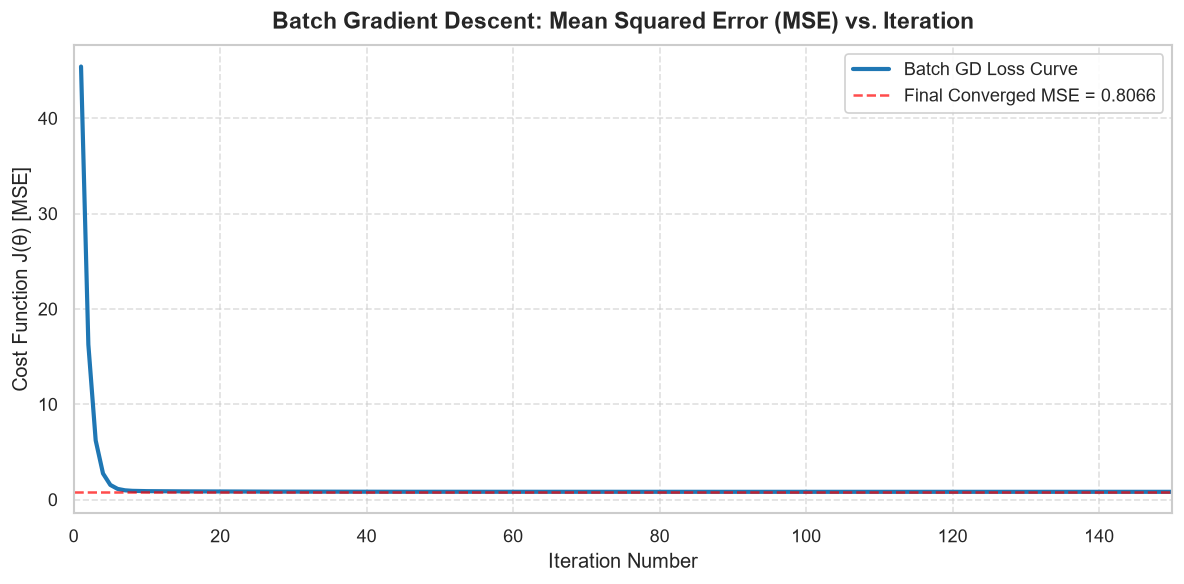

BATCH GRADIENT DESCENT: FINAL PARAMETER CONVERGENCE REPORT


,Parameter,True Population Value,BGD Estimated Value,Normal Equation (OLS),Absolute Error vs OLS
0,θ₀ (Intercept / Bias),4.0,4.215096,4.215096,1.065814e-14
1,θ₁ (Slope / Weight),3.0,2.770113,2.770113,1.110223e-14



Initial Random θ: [0.4967, -0.1383]
Final Converged θ after 1000 iterations: [4.2151, 2.7701]
Final Training MSE: 0.806585


In [2]:
# 1. Generate Synthetic Linear Dataset
np.random.seed(GLOBAL_SEED)
m = 100
X_synth = 2 * np.random.rand(m, 1)
y_synth = 4 + 3 * X_synth + np.random.randn(m, 1)

# Add bias feature x0 = 1 to each instance
X_b = np.c_[np.ones((m, 1)), X_synth]

# 2. Implement Batch Gradient Descent
eta = 0.1
n_iterations = 1000
np.random.seed(GLOBAL_SEED)
theta_bgd = np.random.randn(2, 1)  # Random parameter initialization

bgd_mse_history = []
bgd_theta_history = [theta_bgd.copy()]

for iteration in range(n_iterations):
    # Compute current predictions and MSE
    predictions = X_b.dot(theta_bgd)
    mse = np.mean((predictions - y_synth) ** 2)
    bgd_mse_history.append(mse)
    
    # Compute analytical batch gradient
    gradients = (2 / m) * X_b.T.dot(predictions - y_synth)
    
    # Update parameters
    theta_bgd = theta_bgd - eta * gradients
    bgd_theta_history.append(theta_bgd.copy())

# Calculate closed-form Normal Equation solution for verification: theta = (X_b^T X_b)^(-1) X_b^T y
theta_normal_eq = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_synth)

# 3. Plot MSE vs. Iteration Number
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_iterations + 1), bgd_mse_history, color='#1f77b4', lw=2.5, label='Batch GD Loss Curve')
plt.axhline(y=bgd_mse_history[-1], color='red', linestyle='--', alpha=0.7, label=f'Final Converged MSE = {bgd_mse_history[-1]:.4f}')
plt.title('Batch Gradient Descent: Mean Squared Error (MSE) vs. Iteration', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Iteration Number', fontsize=12)
plt.ylabel('Cost Function J(θ) [MSE]', fontsize=12)
plt.xlim(0, 150)  # Zoom in to display rapid initial descent
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()
plt.show()

# 4. Display Formatted Results
df_bgd_results = pd.DataFrame({
    'Parameter': ['θ₀ (Intercept / Bias)', 'θ₁ (Slope / Weight)'],
    'True Population Value': [4.0000, 3.0000],
    'BGD Estimated Value': [theta_bgd[0, 0], theta_bgd[1, 0]],
    'Normal Equation (OLS)': [theta_normal_eq[0, 0], theta_normal_eq[1, 0]],
    'Absolute Error vs OLS': [abs(theta_bgd[0, 0] - theta_normal_eq[0, 0]), abs(theta_bgd[1, 0] - theta_normal_eq[1, 0])]
})

print("="*75)
print("BATCH GRADIENT DESCENT: FINAL PARAMETER CONVERGENCE REPORT")
print("="*75)
display(df_bgd_results)
print(f"\nInitial Random θ: [{bgd_theta_history[0][0, 0]:.4f}, {bgd_theta_history[0][1, 0]:.4f}]")
print(f"Final Converged θ after {n_iterations} iterations: [{theta_bgd[0, 0]:.4f}, {theta_bgd[1, 0]:.4f}]")
print(f"Final Training MSE: {bgd_mse_history[-1]:.6f}")


---
## 2. Question 2: Stochastic Gradient Descent (SGD) with Dynamic Learning Schedule

### Theoretical Context:
While Batch GD computes gradients using all $m=100$ instances at each step, **Stochastic Gradient Descent (SGD)** picks a single random instance $(\mathbf{x}_b^{(i)}, y^{(i)})$ at every individual step:
$$\mathbf{g}^{(t)} = 2 \mathbf{x}_b^{(i)} \left(\mathbf{x}_b^{(i)T} \boldsymbol{\theta} - y^{(i)}\right)$$
$$\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} - \eta(t) \mathbf{g}^{(t)}$$

Because each step is based on only one sample, the gradient estimate is noisy. To ensure convergence to the global minimum rather than oscillating perpetually around it, a simulated annealing **learning schedule** is employed:
$$\eta(t) = \frac{t_0}{t + t_1}$$
where $t_0 = 5$, $t_1 = 50$, and $t = \text{epoch} \cdot m + i$ is the cumulative step index.

In 50 epochs over $m=100$ instances, SGD performs exactly $50 \times 100 = 5000$ individual parameter updates.


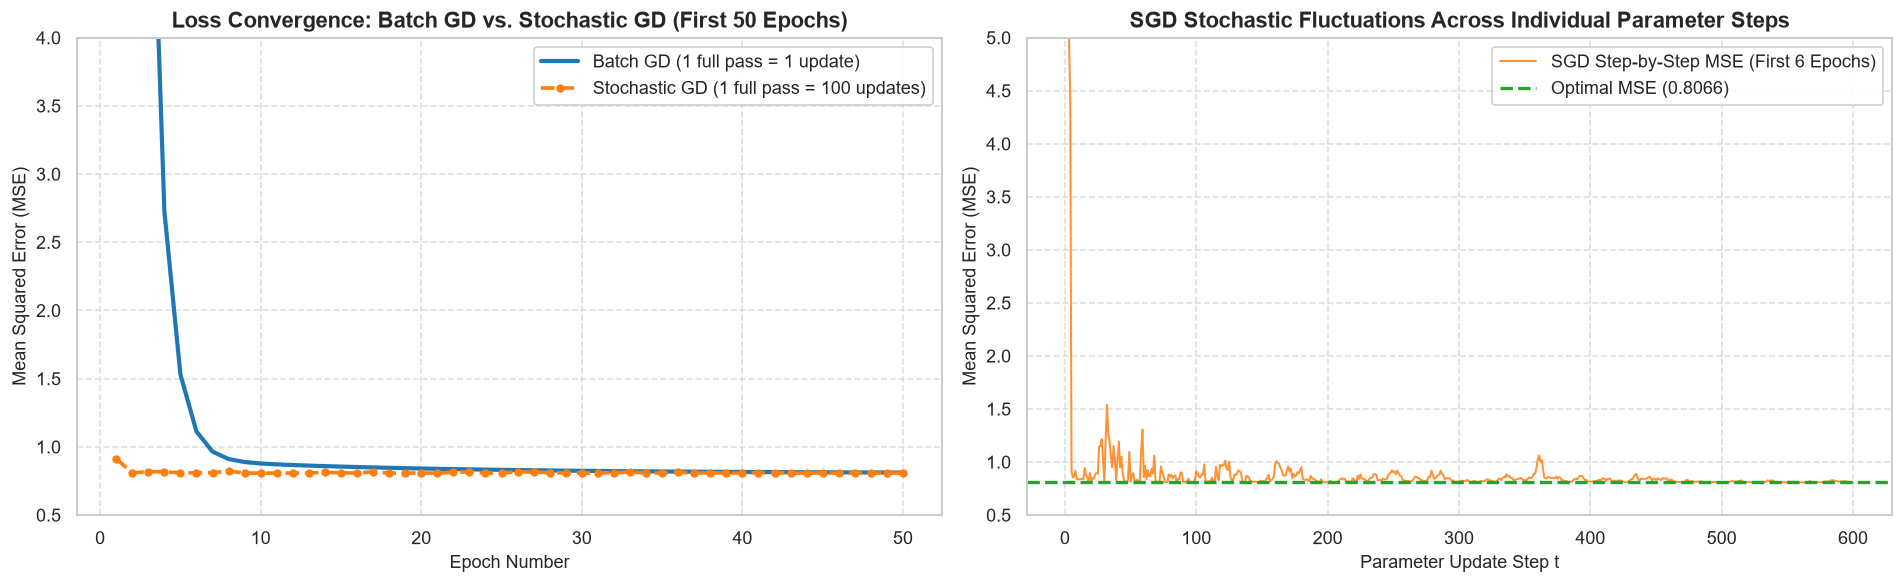

GRADIENT DESCENT COMPARISON: PARAMETER UPDATES & CONVERGENCE


,Optimization Algorithm,Epochs / Passes,Sample Size per Gradient Step,Total Parameter Updates,Final θ₀ (Intercept),Final θ₁ (Slope),Final Full MSE
0,Batch Gradient Descent (BGD),1000,m = 100 (All samples),1000,4.215096,2.770113,0.806585
1,Stochastic Gradient Descent (SGD),50,1 (Single random sample),5000,4.210760,2.748561,0.807353


In [3]:
# Stochastic Gradient Descent Implementation
n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(GLOBAL_SEED)
theta_sgd = np.random.randn(2, 1)  # Same distribution initialization
sgd_step_mse = []
sgd_epoch_mse = []
sgd_theta_history = [theta_sgd.copy()]

total_sgd_updates = 0

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y_synth[random_index:random_index+1]
        
        # Stochastic gradient on single instance
        gradients = 2 * xi.T.dot(xi.dot(theta_sgd) - yi)
        
        # Adaptive learning rate
        t = epoch * m + i
        eta_sgd = learning_schedule(t)
        
        # Parameter update
        theta_sgd = theta_sgd - eta_sgd * gradients
        total_sgd_updates += 1
        
        # Track loss after update
        step_mse = np.mean((X_b.dot(theta_sgd) - y_synth) ** 2)
        sgd_step_mse.append(step_mse)
        
    # Full dataset MSE at end of each epoch
    epoch_mse = np.mean((X_b.dot(theta_sgd) - y_synth) ** 2)
    sgd_epoch_mse.append(epoch_mse)
    sgd_theta_history.append(theta_sgd.copy())

total_bgd_updates = n_iterations  # Batch GD: 1 update per iteration = 1000 updates

# Overlay MSE Trajectories: Batch GD vs SGD
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Epoch-level MSE Comparison (First 50 Epochs / Iterations)
ax1.plot(range(1, 51), bgd_mse_history[:50], color='#1f77b4', lw=2.5, label='Batch GD (1 full pass = 1 update)')
ax1.plot(range(1, 51), sgd_epoch_mse, color='#ff7f0e', lw=2.2, linestyle='--', marker='o', markersize=4, label='Stochastic GD (1 full pass = 100 updates)')
ax1.set_title('Loss Convergence: Batch GD vs. Stochastic GD (First 50 Epochs)', fontweight='bold', fontsize=13)
ax1.set_xlabel('Epoch Number', fontsize=11)
ax1.set_ylabel('Mean Squared Error (MSE)', fontsize=11)
ax1.set_ylim(0.5, 4.0)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9)

# Subplot 2: SGD High-Frequency Step-by-Step Trajectory
ax2.plot(range(1, 601), sgd_step_mse[:600], color='#ff7f0e', lw=1.2, alpha=0.85, label='SGD Step-by-Step MSE (First 6 Epochs)')
ax2.axhline(y=bgd_mse_history[-1], color='#2ca02c', linestyle='--', lw=2, label=f'Optimal MSE ({bgd_mse_history[-1]:.4f})')
ax2.set_title('SGD Stochastic Fluctuations Across Individual Parameter Steps', fontweight='bold', fontsize=13)
ax2.set_xlabel('Parameter Update Step t', fontsize=11)
ax2.set_ylabel('Mean Squared Error (MSE)', fontsize=11)
ax2.set_ylim(0.5, 5.0)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

# Summary table of parameter updates
df_update_comparison = pd.DataFrame({
    'Optimization Algorithm': ['Batch Gradient Descent (BGD)', 'Stochastic Gradient Descent (SGD)'],
    'Epochs / Passes': [1000, 50],
    'Sample Size per Gradient Step': [f'm = {m} (All samples)', '1 (Single random sample)'],
    'Total Parameter Updates': [total_bgd_updates, total_sgd_updates],
    'Final θ₀ (Intercept)': [theta_bgd[0, 0], theta_sgd[0, 0]],
    'Final θ₁ (Slope)': [theta_bgd[1, 0], theta_sgd[1, 0]],
    'Final Full MSE': [bgd_mse_history[-1], sgd_epoch_mse[-1]]
})

print("="*85)
print("GRADIENT DESCENT COMPARISON: PARAMETER UPDATES & CONVERGENCE")
print("="*85)
display(df_update_comparison)


---
## 3. Question 3: Mini-batch Gradient Descent (MBGD) & Multi-Algorithm Synthesis

### Theoretical Framework:
**Mini-batch Gradient Descent** combines the computational efficiency and stability of Batch GD with the rapid iteration and escape capability of SGD. At each step, gradients are computed over a small subset of instances of size $b = 20$:
$$\mathbf{g}^{(t)} = \frac{2}{b} \mathbf{X}_{batch}^T (\mathbf{X}_{batch} \boldsymbol{\theta} - \mathbf{y}_{batch})$$
$$\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} - \eta(t) \mathbf{g}^{(t)}$$

For $m=100$ and $b=20$, each epoch contains $\frac{100}{20} = 5$ mini-batches. Across 50 epochs, MBGD performs $50 \times 5 = 250$ parameter updates.

### Objective:
1. Implement Mini-batch GD with $\text{batch\_size}=20$ and 50 epochs.
2. Track convergence speed and record the exact number of epochs required by Batch GD, SGD, and Mini-batch GD to achieve $\text{MSE} < 1.0$.
3. Report final parameter estimates $\boldsymbol{\theta}$ and convergence metrics in a consolidated comparison table.


TABLE: COMPREHENSIVE PERFORMANCE COMPARISON OF GRADIENT DESCENT VARIANTS


,GD Variant,Batch Size,Epochs Run,Total Parameter Updates,Epochs to reach MSE < 1.0,Final θ₀ (Intercept),Final θ₁ (Slope),Final MSE
0,Batch Gradient Descent,100,1000,1000,7,4.2151,2.7701,0.80658
1,Stochastic Gradient Descent,1,50,5000,1,4.2108,2.7486,0.80735
2,Mini-batch Gradient Descent,20,50,250,2,4.1831,2.7958,0.80688


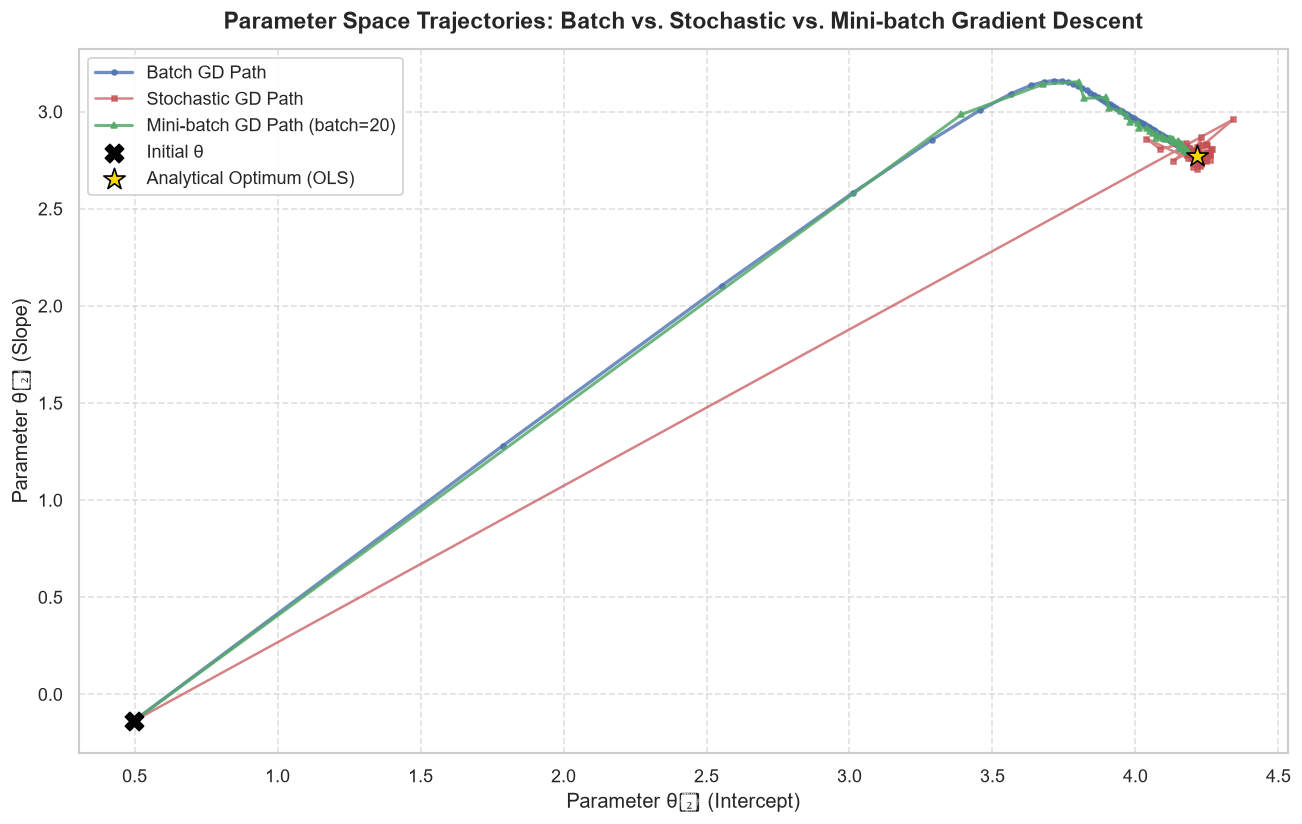

In [4]:
# Mini-batch Gradient Descent Implementation
batch_size = 20
n_batches = int(m / batch_size)
n_epochs_mbgd = 50

np.random.seed(GLOBAL_SEED)
theta_mbgd = np.random.randn(2, 1)

mbgd_epoch_mse = []
mbgd_theta_history = [theta_mbgd.copy()]
total_mbgd_updates = 0

for epoch in range(n_epochs_mbgd):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y_synth[shuffled_indices]
    
    for b_idx in range(0, m, batch_size):
        xi_batch = X_b_shuffled[b_idx:b_idx+batch_size]
        yi_batch = y_shuffled[b_idx:b_idx+batch_size]
        
        # Mini-batch gradient
        gradients = (2 / batch_size) * xi_batch.T.dot(xi_batch.dot(theta_mbgd) - yi_batch)
        
        # Adaptive learning rate based on mini-batch step
        t = epoch * n_batches + (b_idx // batch_size)
        eta_mbgd = learning_schedule(t)
        
        theta_mbgd = theta_mbgd - eta_mbgd * gradients
        total_mbgd_updates += 1
        
    epoch_mse = np.mean((X_b.dot(theta_mbgd) - y_synth) ** 2)
    mbgd_epoch_mse.append(epoch_mse)
    mbgd_theta_history.append(theta_mbgd.copy())

# Calculate epochs taken to reach MSE < 1.0
def find_epochs_to_threshold(mse_list, threshold=1.0):
    for epoch_idx, mse_val in enumerate(mse_list, start=1):
        if mse_val < threshold:
            return epoch_idx
    return None

bgd_epochs_to_1 = find_epochs_to_threshold(bgd_mse_history, threshold=1.0)
sgd_epochs_to_1 = find_epochs_to_threshold(sgd_epoch_mse, threshold=1.0)
mbgd_epochs_to_1 = find_epochs_to_threshold(mbgd_epoch_mse, threshold=1.0)

# Build comprehensive summary comparison table
df_gd_all = pd.DataFrame({
    'GD Variant': ['Batch Gradient Descent', 'Stochastic Gradient Descent', 'Mini-batch Gradient Descent'],
    'Batch Size': [m, 1, batch_size],
    'Epochs Run': [n_iterations, n_epochs, n_epochs_mbgd],
    'Total Parameter Updates': [total_bgd_updates, total_sgd_updates, total_mbgd_updates],
    'Epochs to reach MSE < 1.0': [bgd_epochs_to_1, sgd_epochs_to_1, mbgd_epochs_to_1],
    'Final θ₀ (Intercept)': [round(theta_bgd[0, 0], 4), round(theta_sgd[0, 0], 4), round(theta_mbgd[0, 0], 4)],
    'Final θ₁ (Slope)': [round(theta_bgd[1, 0], 4), round(theta_sgd[1, 0], 4), round(theta_mbgd[1, 0], 4)],
    'Final MSE': [round(bgd_mse_history[-1], 5), round(sgd_epoch_mse[-1], 5), round(mbgd_epoch_mse[-1], 5)]
})

print("="*95)
print("TABLE: COMPREHENSIVE PERFORMANCE COMPARISON OF GRADIENT DESCENT VARIANTS")
print("="*95)
display(df_gd_all)

# Visualization: Trajectories in Parameter Space (θ₀ vs θ₁)
plt.figure(figsize=(11, 7))

# Convert histories to numpy arrays
bgd_hist_arr = np.array(bgd_theta_history).squeeze()
sgd_hist_arr = np.array(sgd_theta_history).squeeze()
mbgd_hist_arr = np.array(mbgd_theta_history).squeeze()

plt.plot(bgd_hist_arr[:, 0], bgd_hist_arr[:, 1], 'b-o', markersize=3, lw=2, label='Batch GD Path', alpha=0.8)
plt.plot(sgd_hist_arr[:, 0], sgd_hist_arr[:, 1], 'r-s', markersize=3, lw=1.5, label='Stochastic GD Path', alpha=0.7)
plt.plot(mbgd_hist_arr[:, 0], mbgd_hist_arr[:, 1], 'g-^', markersize=4, lw=1.8, label='Mini-batch GD Path (batch=20)', alpha=0.85)

# Highlight start and global optimum
plt.scatter([bgd_hist_arr[0, 0]], [bgd_hist_arr[0, 1]], color='black', s=120, zorder=5, marker='X', label='Initial θ')
plt.scatter([theta_normal_eq[0, 0]], [theta_normal_eq[1, 0]], color='gold', edgecolor='black', s=180, zorder=6, marker='*', label='Analytical Optimum (OLS)')

plt.title('Parameter Space Trajectories: Batch vs. Stochastic vs. Mini-batch Gradient Descent', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Parameter θ₀ (Intercept)', fontsize=12)
plt.ylabel('Parameter θ₁ (Slope)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()
plt.show()


---
## 4. Question 4: Polynomial Regression, Overfitting & Diagnostic Learning Curves

### Mathematical Formulation:
We generate non-linear quadratic data according to:
$$y = 0.5 X^2 + X + 2 + \epsilon, \quad X \in [-3, 3], \quad \epsilon \sim \mathcal{N}(0, 1)$$

We fit three polynomial regression models using `PolynomialFeatures(degree=d)`:
1. **Degree 1 (Linear):** Underfitting / High Bias ($\hat{y} = \theta_0 + \theta_1 X$). Incapable of capturing curvature.
2. **Degree 2 (Quadratic):** Ground Truth / Optimal Bias-Variance Balance ($\hat{y} = \theta_0 + \theta_1 X + \theta_2 X^2$).
3. **Degree 300 (High-Degree Polynomial):** Severe Overfitting / High Variance. Fits noise fluctuations in the training set and generalizes poorly.

### Learning Curves:
Learning curves plot model training RMSE and validation RMSE as a function of training-set size ($m_{train} = 1, 2, \dots$).
- **Underfitting (Degree 1):** Both curves plateau early at a high error with virtually zero gap between them.
- **Overfitting (Degree 300):** Training error remains near zero, while validation error is massive, manifesting a large generalization gap.


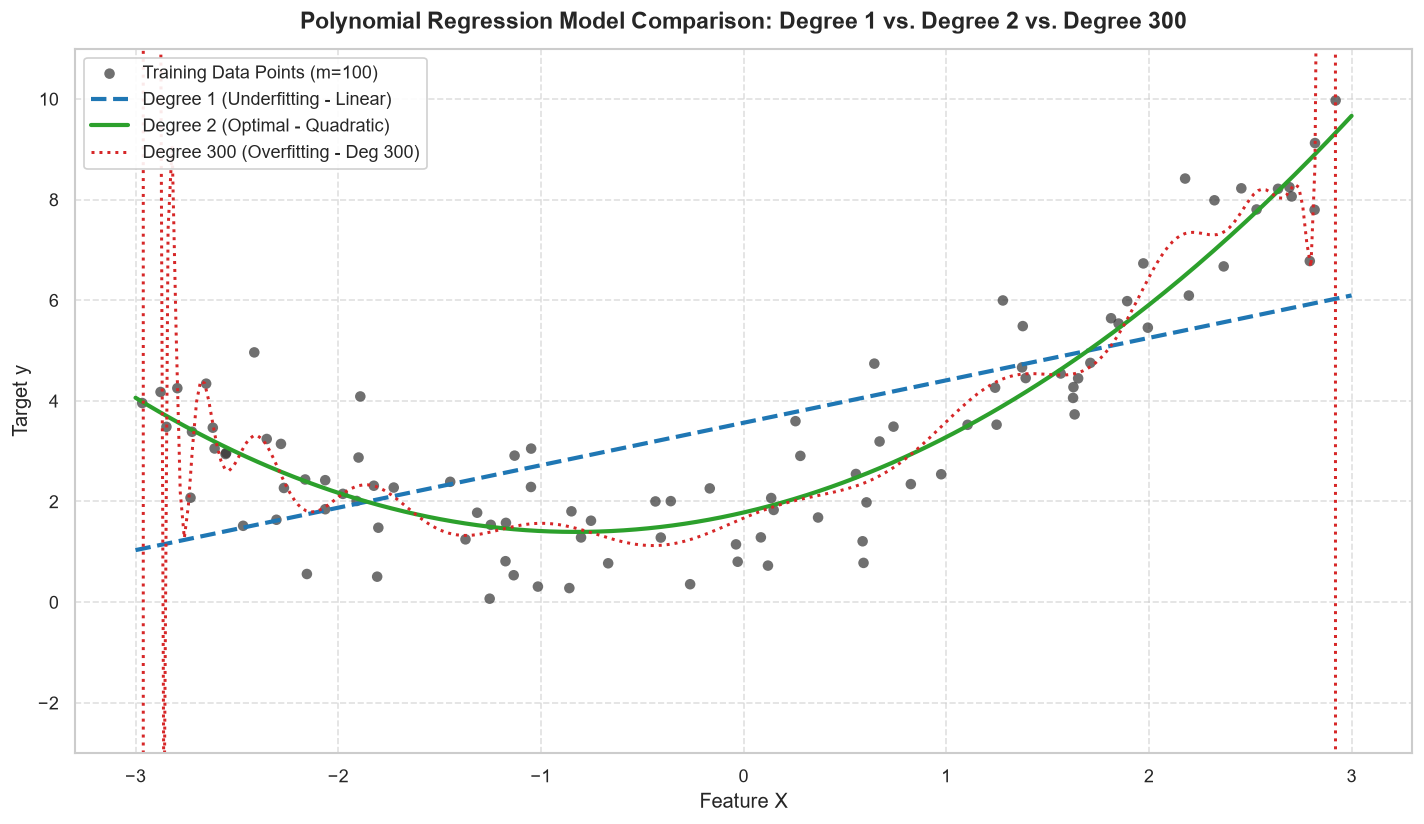

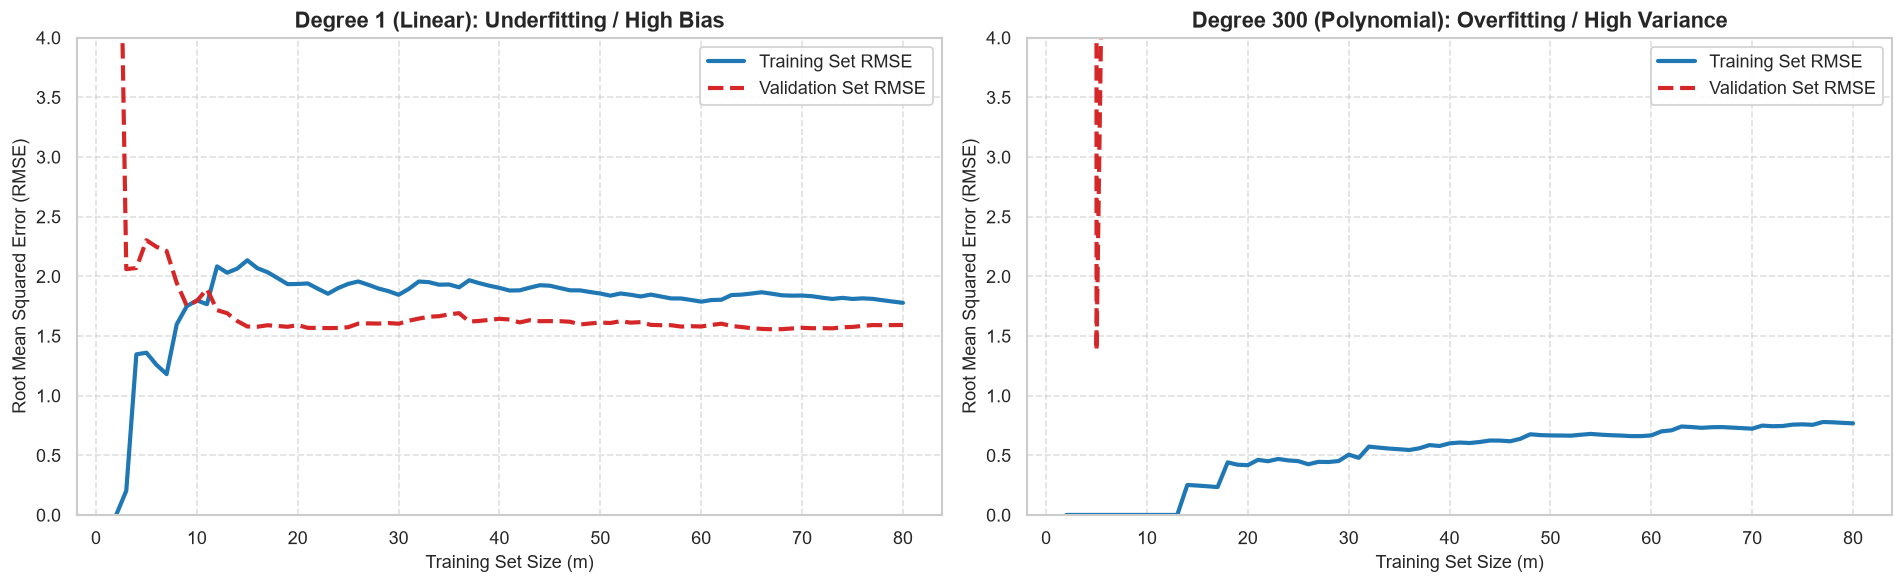

Key Diagnostic Takeaways:
1. Degree 1 Learning Curve: Both train and val errors plateau at high RMSE (~1.80) with minimal gap -> High Bias (Underfitting).
2. Degree 300 Learning Curve: Training error is close to 0 while validation error remains elevated -> High Variance (Overfitting).


In [5]:
# 1. Generate Synthetic Quadratic Data
np.random.seed(GLOBAL_SEED)
m_poly = 100
X_poly = 6 * np.random.rand(m_poly, 1) - 3
y_poly = 0.5 * (X_poly ** 2) + X_poly + 2 + np.random.randn(m_poly, 1)

# Generate dense grid for smooth curve visualization
X_grid = np.linspace(-3, 3, 300).reshape(-300, 1)

# Fit models of degree 1, 2, and 300
degrees = [1, 2, 300]
colors = ['#1f77b4', '#2ca02c', '#d62728']
styles = ['--', '-', ':']
fitted_models = {}

plt.figure(figsize=(12, 7))
plt.scatter(X_poly, y_poly, color='#333333', alpha=0.7, s=40, edgecolors='none', label='Training Data Points (m=100)')

for degree, color, style in zip(degrees, colors, styles):
    # Pipeline with StandardScaler to ensure numerical stability for degree 300
    model = Pipeline([
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lin_reg', LinearRegression())
    ])
    model.fit(X_poly, y_poly)
    fitted_models[degree] = model
    
    y_grid_pred = model.predict(X_grid)
    label_name = f'Degree {degree}' + (' (Underfitting - Linear)' if degree==1 else (' (Optimal - Quadratic)' if degree==2 else ' (Overfitting - Deg 300)'))
    plt.plot(X_grid, y_grid_pred, color=color, linestyle=style, lw=2.5 if degree!=300 else 1.8, label=label_name)

plt.title('Polynomial Regression Model Comparison: Degree 1 vs. Degree 2 vs. Degree 300', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Feature X', fontsize=12)
plt.ylabel('Target y', fontsize=12)
plt.ylim(-3, 11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

# 2. Compute and Plot Diagnostic Learning Curves
def compute_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=GLOBAL_SEED)
    train_errors, val_errors = [], []
    
    for m_subset in range(2, len(X_train) + 1):
        model.fit(X_train[:m_subset], y_train[:m_subset])
        y_train_predict = model.predict(X_train[:m_subset])
        y_val_predict = model.predict(X_val)
        
        train_rmse = np.sqrt(mean_squared_error(y_train[:m_subset], y_train_predict))
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_predict))
        
        train_errors.append(train_rmse)
        val_errors.append(val_rmse)
        
    return train_errors, val_errors

train_err_deg1, val_err_deg1 = compute_learning_curves(fitted_models[1], X_poly, y_poly)
train_err_deg300, val_err_deg300 = compute_learning_curves(fitted_models[300], X_poly, y_poly)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Learning Curve for Degree 1 (Underfitting / High Bias)
ax1.plot(range(2, len(train_err_deg1) + 2), train_err_deg1, color='#1f77b4', lw=2.5, label='Training Set RMSE')
ax1.plot(range(2, len(val_err_deg1) + 2), val_err_deg1, color='#d62728', lw=2.5, linestyle='--', label='Validation Set RMSE')
ax1.set_title('Degree 1 (Linear): Underfitting / High Bias', fontweight='bold', fontsize=13)
ax1.set_xlabel('Training Set Size (m)', fontsize=11)
ax1.set_ylabel('Root Mean Squared Error (RMSE)', fontsize=11)
ax1.set_ylim(0, 4.0)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9)

# Subplot 2: Learning Curve for Degree 300 (Overfitting / High Variance)
ax2.plot(range(2, len(train_err_deg300) + 2), train_err_deg300, color='#1f77b4', lw=2.5, label='Training Set RMSE')
ax2.plot(range(2, len(val_err_deg300) + 2), val_err_deg300, color='#d62728', lw=2.5, linestyle='--', label='Validation Set RMSE')
ax2.set_title('Degree 300 (Polynomial): Overfitting / High Variance', fontweight='bold', fontsize=13)
ax2.set_xlabel('Training Set Size (m)', fontsize=11)
ax2.set_ylabel('Root Mean Squared Error (RMSE)', fontsize=11)
ax2.set_ylim(0, 4.0)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

print("Key Diagnostic Takeaways:")
print("1. Degree 1 Learning Curve: Both train and val errors plateau at high RMSE (~1.80) with minimal gap -> High Bias (Underfitting).")
print("2. Degree 300 Learning Curve: Training error is close to 0 while validation error remains elevated -> High Variance (Overfitting).")


---
## 5. Question 5: Regularized Linear Models on UCI Wine Quality Dataset

### Theoretical Overview:
To constrain overfitting in multivariate regression, we incorporate parameter penalty regularization terms into the cost function:

1. **Ridge Regression ($L_2$ Regularization):**
   $$J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + \alpha \sum_{i=1}^n \theta_i^2$$
   Shrinks all weights smoothly toward zero but never forces them exactly to zero.

2. **Lasso Regression ($L_1$ Regularization):**
   $$J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + \alpha \sum_{i=1}^n |\theta_i|$$
   Forces less important feature coefficients to become **identically zero**, acting as automated feature selection.

3. **Elastic Net (Combined $L_1$ and $L_2$):**
   $$J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + r \alpha \sum_{i=1}^n |\theta_i| + \frac{1-r}{2} \alpha \sum_{i=1}^n \theta_i^2 \quad (\text{with } r = 0.5)$$

### Requirements:
1. Load `winequality-red.csv` (semicolon-delimited) and standardize features.
2. Train Ridge, Lasso, and ElasticNet models across $\alpha \in \{0.001, 0.01, 0.1, 1, 10\}$.
3. Report Test RMSE for all $(\text{model}, \alpha)$ pairs in a clean pivot table.
4. Plot Lasso coefficient shrinkage paths vs. $\alpha$ for each feature and determine which feature shrinks to zero first.


Wine Quality Dataset Loaded: 1599 rows, 12 columns


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


TABLE: TEST RMSE FOR RIDGE, LASSO, AND ELASTICNET ACROSS ALPHAS


Alpha,0.001,0.010,0.100,1.000,10.000
Model,,,,,
ElasticNet (L1+L2),0.624701,0.626290,0.644144,0.810654,0.810654
Lasso (L1),0.624881,0.626909,0.662740,0.810654,0.810654
Ridge (L2),0.624520,0.624520,0.624521,0.624530,0.624641



LASSO FEATURE ELIMINATION ORDER (FIRST TO HIT ZERO):


,Feature,Alpha at which Coefficient Hits Zero
0,residual sugar,0.002736
1,density,0.003108
2,citric acid,0.005511
3,free sulfur dioxide,0.019677
4,pH,0.042231
5,chlorides,0.058052
6,fixed acidity,0.061867
7,total sulfur dioxide,0.096588
8,sulphates,0.150797
9,volatile acidity,0.284953


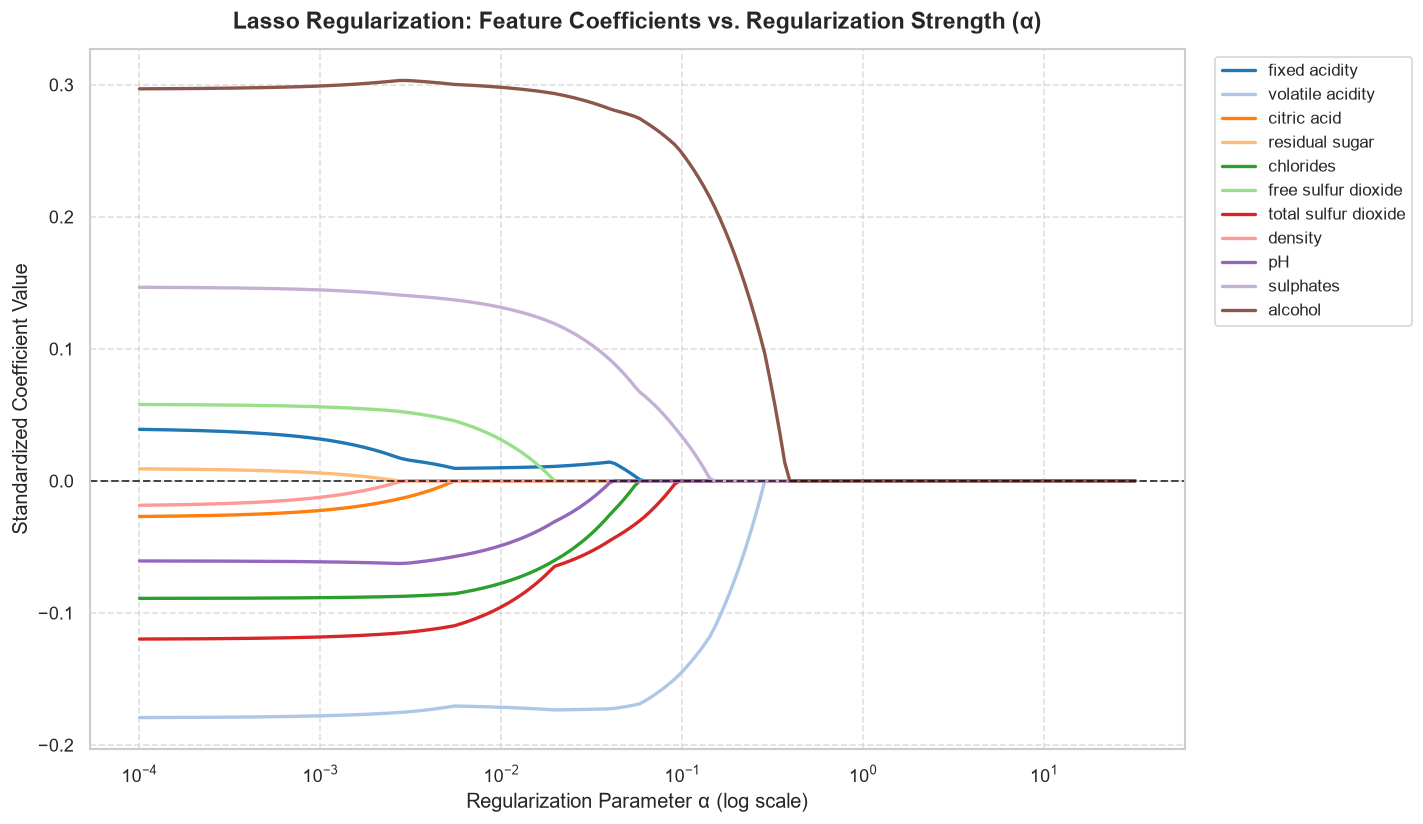


Conclusion: 'residual sugar' is the first feature whose coefficient reaches zero (at α ≈ 0.00274).


In [6]:
# 1. Load and Inspect UCI Wine Quality Dataset
wine_csv_path = 'winequality-red.csv'
wine_df = pd.read_csv(wine_csv_path, sep=';')

print(f"Wine Quality Dataset Loaded: {wine_df.shape[0]} rows, {wine_df.shape[1]} columns")
display(wine_df.head(5))

# Prepare features and target
X_wine = wine_df.drop(columns=['quality'])
y_wine = wine_df['quality']
feature_names = X_wine.columns.tolist()

# 80/20 Train-Test Split with StandardScaler
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=GLOBAL_SEED
)

scaler_w = StandardScaler()
X_train_w_scaled = scaler_w.fit_transform(X_train_w)
X_test_w_scaled = scaler_w.transform(X_test_w)

# 2. Evaluate Models Across Alpha Hyperparameters
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
results_q5 = []

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha, random_state=GLOBAL_SEED)
    ridge.fit(X_train_w_scaled, y_train_w)
    ridge_rmse = np.sqrt(mean_squared_error(y_test_w, ridge.predict(X_test_w_scaled)))
    results_q5.append({'Model': 'Ridge (L2)', 'Alpha': alpha, 'Test RMSE': ridge_rmse})
    
    # Lasso
    lasso = Lasso(alpha=alpha, random_state=GLOBAL_SEED, max_iter=20000)
    lasso.fit(X_train_w_scaled, y_train_w)
    lasso_rmse = np.sqrt(mean_squared_error(y_test_w, lasso.predict(X_test_w_scaled)))
    results_q5.append({'Model': 'Lasso (L1)', 'Alpha': alpha, 'Test RMSE': lasso_rmse})
    
    # ElasticNet (l1_ratio = 0.5)
    enet = ElasticNet(alpha=alpha, l1_ratio=0.5, random_state=GLOBAL_SEED, max_iter=20000)
    enet.fit(X_train_w_scaled, y_train_w)
    enet_rmse = np.sqrt(mean_squared_error(y_test_w, enet.predict(X_test_w_scaled)))
    results_q5.append({'Model': 'ElasticNet (L1+L2)', 'Alpha': alpha, 'Test RMSE': enet_rmse})

df_rmse_summary = pd.DataFrame(results_q5)
pivot_rmse = df_rmse_summary.pivot(index='Model', columns='Alpha', values='Test RMSE')

print("="*85)
print("TABLE: TEST RMSE FOR RIDGE, LASSO, AND ELASTICNET ACROSS ALPHAS")
print("="*85)
display(pivot_rmse)

# 3. Lasso Coefficient Paths vs. Alpha
dense_alphas = np.logspace(-4, 1.5, 200)
lasso_coef_paths = []

for a in dense_alphas:
    l_model = Lasso(alpha=a, random_state=GLOBAL_SEED, max_iter=20000)
    l_model.fit(X_train_w_scaled, y_train_w)
    lasso_coef_paths.append(l_model.coef_)

lasso_coef_paths = np.array(lasso_coef_paths)

# Identify which feature coefficient reaches zero first
# We evaluate starting from small alpha and find the earliest alpha where |coef| < 1e-6
zero_alpha_dict = {}
for idx, feat in enumerate(feature_names):
    # Check where coefficient magnitude is strictly 0
    zero_indices = np.where(np.abs(lasso_coef_paths[:, idx]) < 1e-7)[0]
    if len(zero_indices) > 0:
        first_zero_alpha = dense_alphas[zero_indices[0]]
        zero_alpha_dict[feat] = first_zero_alpha
    else:
        zero_alpha_dict[feat] = np.inf

df_zero_ranking = pd.DataFrame({
    'Feature': list(zero_alpha_dict.keys()),
    'Alpha at which Coefficient Hits Zero': list(zero_alpha_dict.values())
}).sort_values(by='Alpha at which Coefficient Hits Zero', ascending=True).reset_index(drop=True)

print("\n" + "="*85)
print("LASSO FEATURE ELIMINATION ORDER (FIRST TO HIT ZERO):")
print("="*85)
display(df_zero_ranking)

# Plot Lasso Coefficient Paths
plt.figure(figsize=(12, 7))
palette_colors = sns.color_palette('tab20', len(feature_names))

for idx, feat in enumerate(feature_names):
    plt.plot(dense_alphas, lasso_coef_paths[:, idx], label=feat, lw=2.0, color=palette_colors[idx])

plt.xscale('log')
plt.axhline(0, color='black', linestyle='--', alpha=0.7, lw=1.2)
plt.title("Lasso Regularization: Feature Coefficients vs. Regularization Strength (α)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Regularization Parameter α (log scale)", fontsize=12)
plt.ylabel("Standardized Coefficient Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, facecolor='white', fontsize=10)
plt.tight_layout()
plt.show()

earliest_feature = df_zero_ranking.iloc[0]['Feature']
earliest_alpha = df_zero_ranking.iloc[0]['Alpha at which Coefficient Hits Zero']
print(f"\nConclusion: '{earliest_feature}' is the first feature whose coefficient reaches zero (at α ≈ {earliest_alpha:.5f}).")


---
## 6. Question 6: Binary Classification of Wine Quality via Logistic Regression

### Problem Formulation:
Wine quality is binarized into two distinct quality classes:
$$y_{binary} = \begin{cases} 1 \ (\text{Good Wine}), & \text{if } \text{quality} \ge 7 \\ 0 \ (\text{Not Good Wine}), & \text{if } \text{quality} < 7 \end{cases}$$

### Logistic Regression Model:
$$\hat{p} = \sigma(\mathbf{x}^T \boldsymbol{\theta}) = \frac{1}{1 + e^{-\mathbf{x}^T \boldsymbol{\theta}}}$$
$$\hat{y} = \begin{cases} 1, & \text{if } \hat{p} \ge 0.5 \\ 0, & \text{if } \hat{p} < 0.5 \end{cases}$$

### Classification Performance Metrics:
- **Accuracy:** $\frac{TP + TN}{TP + TN + FP + FN}$ (Total correctness)
- **Precision:** $\frac{TP}{TP + FP}$ (Reliability of positive predictions)
- **Recall (Sensitivity):** $\frac{TP}{TP + FN}$ (Detection rate of actual good wines)
- **F1-Score:** $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ (Harmonic mean)


Wine Quality Class Distribution:
Not Good (<7): 1382 (86.43%)
Good (>=7):     217 (13.57%)

LOGISTIC REGRESSION BINARY CLASSIFICATION METRICS


,Metric,Value
0,Accuracy,0.8938 (89.38%)
1,Precision (Good Wine),0.6957 (69.57%)
2,Recall (Good Wine),0.3721 (37.21%)
3,F1-Score (Good Wine),0.4848



Detailed Classification Report:
               precision    recall  f1-score   support

Not Good (<7)       0.91      0.97      0.94       277
   Good (>=7)       0.70      0.37      0.48        43

     accuracy                           0.89       320
    macro avg       0.80      0.67      0.71       320
 weighted avg       0.88      0.89      0.88       320



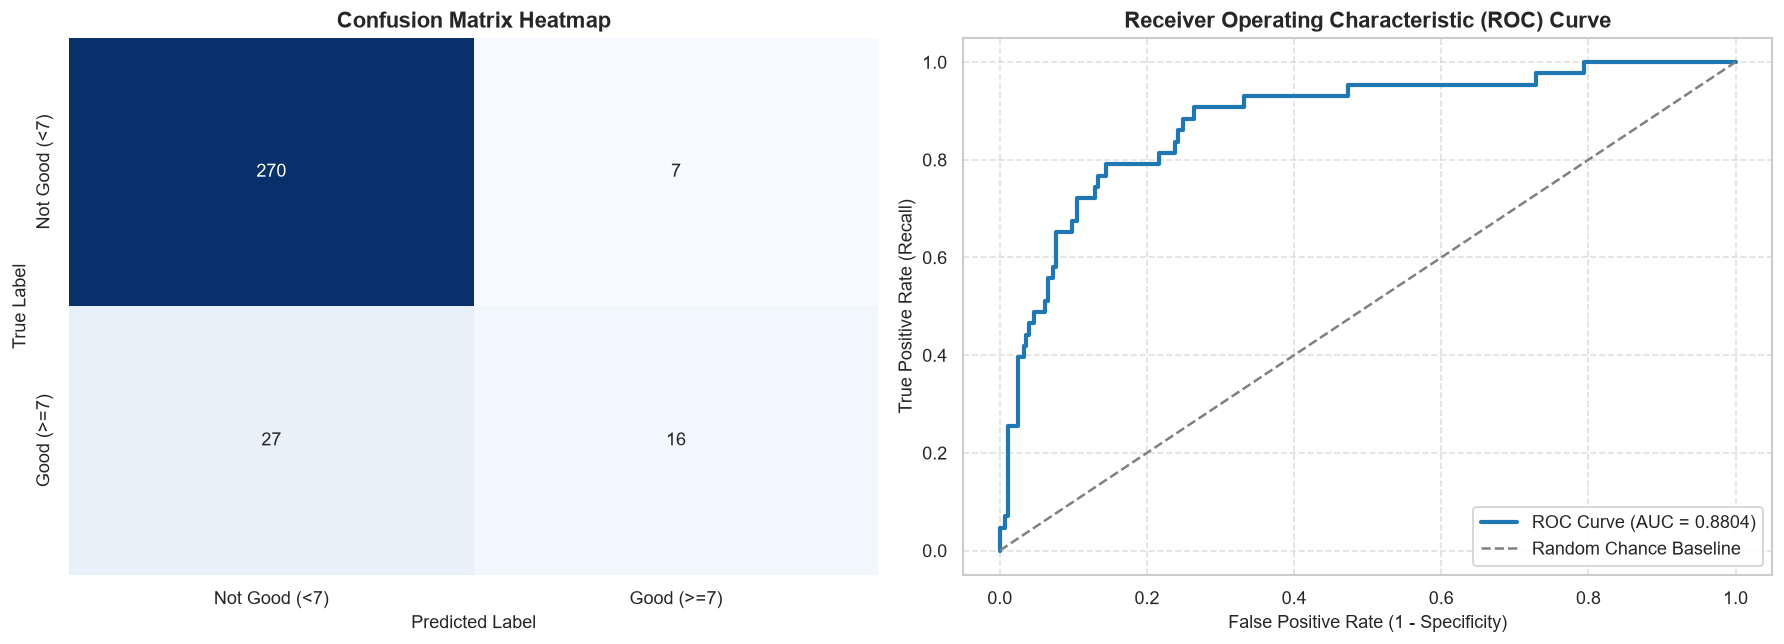

In [7]:
# 1. Binarize Target Variable
y_wine_binary = (y_wine >= 7).astype(int)

class_dist = pd.Series(y_wine_binary).value_counts().rename(index={0: 'Not Good (<7)', 1: 'Good (>=7)'})
print("Wine Quality Class Distribution:")
print(f"Not Good (<7): {class_dist['Not Good (<7)']} ({class_dist['Not Good (<7)']/len(y_wine_binary)*100:.2f}%)")
print(f"Good (>=7):     {class_dist['Good (>=7)']} ({class_dist['Good (>=7)']/len(y_wine_binary)*100:.2f}%)")

# 2. Stratified 80/20 Train-Test Split
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_wine, y_wine_binary, test_size=0.2, random_state=GLOBAL_SEED, stratify=y_wine_binary
)

# Standardize features
scaler_clf = StandardScaler()
X_tr_b_scaled = scaler_clf.fit_transform(X_tr_b)
X_te_b_scaled = scaler_clf.transform(X_te_b)

# 3. Fit Logistic Regression
log_clf = LogisticRegression(random_state=GLOBAL_SEED, max_iter=1000)
log_clf.fit(X_tr_b_scaled, y_tr_b)

y_pred_b = log_clf.predict(X_te_b_scaled)
y_proba_b = log_clf.predict_proba(X_te_b_scaled)[:, 1]

# 4. Compute Performance Metrics
acc_val = accuracy_score(y_te_b, y_pred_b)
prec_val = precision_score(y_te_b, y_pred_b)
rec_val = recall_score(y_te_b, y_pred_b)
f1_val = f1_score(y_te_b, y_pred_b)

df_clf_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Good Wine)', 'Recall (Good Wine)', 'F1-Score (Good Wine)'],
    'Value': [f"{acc_val:.4f} ({acc_val*100:.2f}%)", f"{prec_val:.4f} ({prec_val*100:.2f}%)", f"{rec_val:.4f} ({rec_val*100:.2f}%)", f"{f1_val:.4f}"]
})

print("\n" + "="*70)
print("LOGISTIC REGRESSION BINARY CLASSIFICATION METRICS")
print("="*70)
display(df_clf_metrics)

print("\nDetailed Classification Report:")
print(classification_report(y_te_b, y_pred_b, target_names=['Not Good (<7)', 'Good (>=7)']))

# 5. Diagnostic Plots: Confusion Matrix & ROC Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_te_b, y_pred_b)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Not Good (<7)', 'Good (>=7)'],
            yticklabels=['Not Good (<7)', 'Good (>=7)'])
ax1.set_title('Confusion Matrix Heatmap', fontweight='bold', fontsize=13)
ax1.set_xlabel('Predicted Label', fontsize=11)
ax1.set_ylabel('True Label', fontsize=11)

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_te_b, y_proba_b)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Chance Baseline')
ax2.set_title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold', fontsize=13)
ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax2.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()


---
## 7. Question 7: Multiclass Softmax Regression on Iris Dataset

### Theoretical Formulation:
For multiclass classification with $K=3$ classes (Iris Setosa, Versicolor, Virginica), **Softmax Regression (Multinomial Logistic Regression)** computes a linear score $s_k(\mathbf{x})$ for each class:
$$s_k(\mathbf{x}) = \mathbf{x}^T \boldsymbol{\theta}^{(k)}$$

The probability that instance $\mathbf{x}$ belongs to class $k$ is given by the normalized exponential Softmax function:
$$\hat{p}_k = \sigma(\mathbf{s}(\mathbf{x}))_k = \frac{\exp\left(s_k(\mathbf{x})\right)}{\sum_{j=1}^K \exp\left(s_j(\mathbf{x})\right)}$$

The predicted class $\hat{y}$ is the one with the highest estimated probability:
$$\hat{y} = \arg\max_k \hat{p}_k$$

### Requirement:
Using only **Petal Length (cm)** and **Petal Width (cm)**, fit `LogisticRegression` (with multinomial cross-entropy) and construct a 2D filled decision boundary contour map overlaid with the original dataset points.


Iris Dataset Loaded: 150 instances across 3 classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Softmax Regression Model Training Accuracy: 96.00%



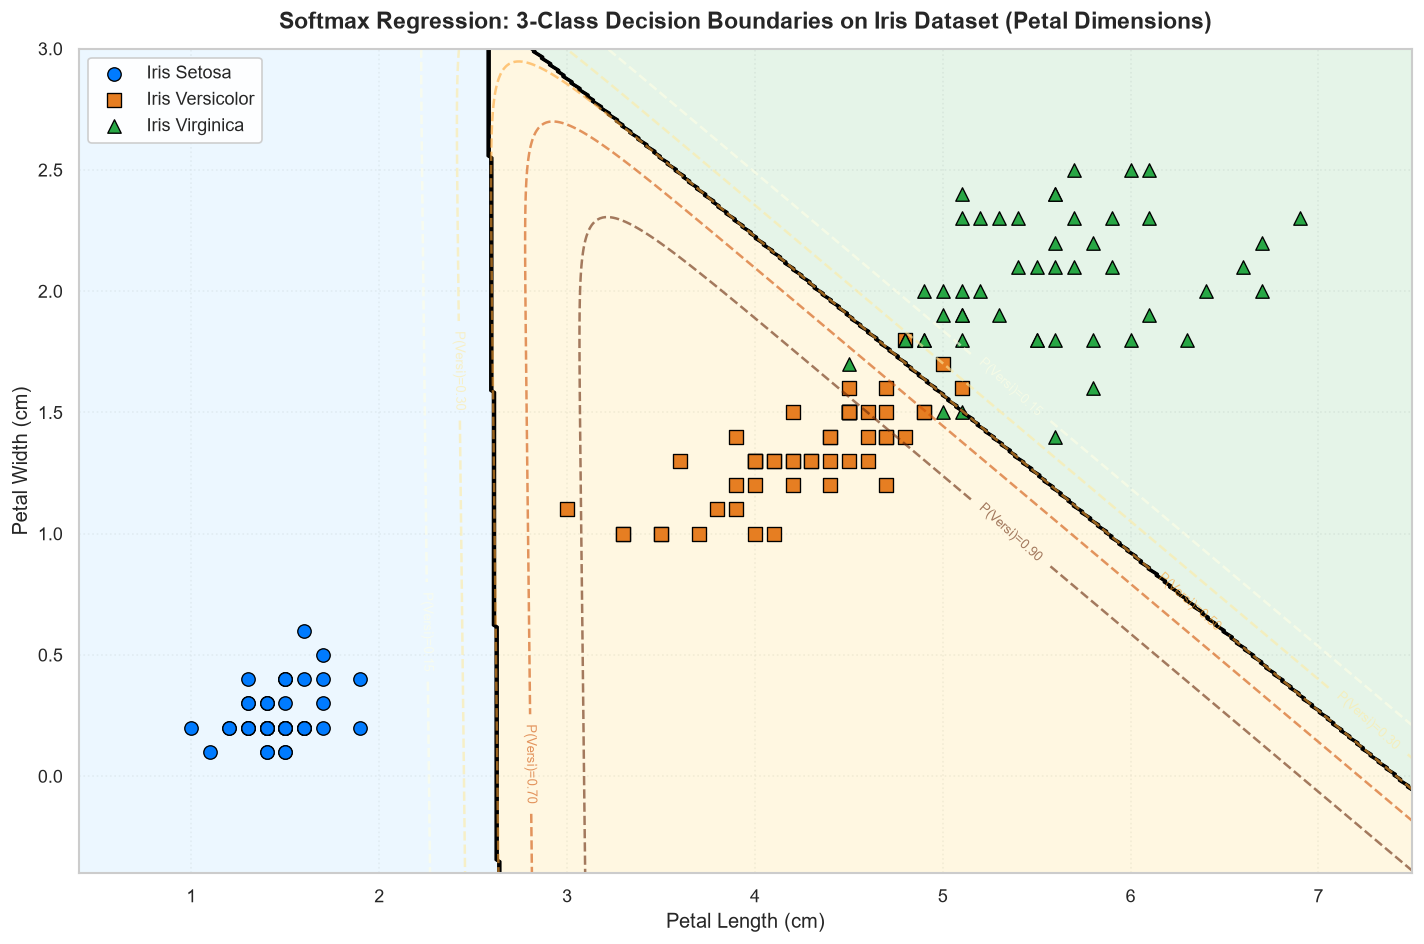

SOFTMAX REGRESSION: LEARNED CLASS PARAMETERS


,Weight (Petal Length),Weight (Petal Width),Bias (Intercept)
Class 0: Setosa,-4.600343,-2.233913,18.914700
Class 1: Versicolor,0.161940,-2.163788,6.395711
Class 2: Virginica,4.438403,4.397701,-25.310411


In [8]:
# 1. Load Iris Dataset
iris = load_iris(as_frame=True)
iris_df = iris.frame

# Select only petal length and petal width features
X_iris = iris.data[['petal length (cm)', 'petal width (cm)']].values
y_iris = iris.target.values
target_names = iris.target_names

print(f"Iris Dataset Loaded: {len(X_iris)} instances across 3 classes: {list(target_names)}")

# 2. Fit Softmax Regression (Multinomial Logistic Regression)
# In Scikit-Learn (1.8+), solver='lbfgs' fits multinomial cross-entropy
softmax_reg = LogisticRegression(solver='lbfgs', C=10, random_state=GLOBAL_SEED)
softmax_reg.fit(X_iris, y_iris)

train_acc_iris = softmax_reg.score(X_iris, y_iris)
print(f"Softmax Regression Model Training Accuracy: {train_acc_iris * 100:.2f}%\n")

# 3. Create 2D Meshgrid for Decision Boundary Visualization
x0_min, x0_max = X_iris[:, 0].min() - 0.6, X_iris[:, 0].max() + 0.6
x1_min, x1_max = X_iris[:, 1].min() - 0.5, X_iris[:, 1].max() + 0.5

x0_grid, x1_grid = np.meshgrid(
    np.linspace(x0_min, x0_max, 500),
    np.linspace(x1_min, x1_max, 500)
)

grid_instances = np.c_[x0_grid.ravel(), x1_grid.ravel()]
y_grid_proba = softmax_reg.predict_proba(grid_instances)
y_grid_pred = softmax_reg.predict(grid_instances).reshape(x0_grid.shape)

# 4. Plot Decision Boundaries and Filled Probability Contours
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#e0f3ff', '#fff3cd', '#d4edda'])
point_colors = ['#007bff', '#e67e22', '#28a745']
point_markers = ['o', 's', '^']

plt.figure(figsize=(12, 8))

# Filled contour regions representing predicted classes
plt.contourf(x0_grid, x1_grid, y_grid_pred, cmap=custom_cmap, alpha=0.6)

# Decision boundary contour lines
plt.contour(x0_grid, x1_grid, y_grid_pred, colors='black', linewidths=1.5, linestyles='-')

# Class probability level contours for Versicolor (Class 1) and Virginica (Class 2)
proba_versicolor = y_grid_proba[:, 1].reshape(x0_grid.shape)
proba_virginica = y_grid_proba[:, 2].reshape(x0_grid.shape)
c1 = plt.contour(x0_grid, x1_grid, proba_versicolor, levels=[0.15, 0.30, 0.50, 0.70, 0.90], cmap='YlOrBr', linestyles='--', alpha=0.6)
plt.clabel(c1, inline=True, fontsize=8, fmt='P(Versi)=%.2f')

# Overlay scatter points of actual Iris instances
for class_idx, (name, color, marker) in enumerate(zip(target_names, point_colors, point_markers)):
    idx_mask = (y_iris == class_idx)
    plt.scatter(
        X_iris[idx_mask, 0], X_iris[idx_mask, 1],
        color=color, marker=marker, s=65, edgecolors='black', lw=0.8,
        label=f'Iris {name.capitalize()}'
    )

plt.title('Softmax Regression: 3-Class Decision Boundaries on Iris Dataset (Petal Dimensions)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.xlim(x0_min, x0_max)
plt.ylim(x1_min, x1_max)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.95, fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

# Display Model Coefficients & Intercepts Table
df_softmax_params = pd.DataFrame(
    softmax_reg.coef_,
    index=[f"Class {i}: {name.capitalize()}" for i, name in enumerate(target_names)],
    columns=['Weight (Petal Length)', 'Weight (Petal Width)']
)
df_softmax_params['Bias (Intercept)'] = softmax_reg.intercept_

print("="*85)
print("SOFTMAX REGRESSION: LEARNED CLASS PARAMETERS")
print("="*85)
display(df_softmax_params)


---
## 8. Final Synthesis & Comprehensive Summary

### Summary Table of All Assignment 5 Modules:
| Question | Module / Task | Key Findings & Metric Values | Theoretical Takeaways |
| :--- | :--- | :--- | :--- |
| **Q1** | **Batch GD from Scratch** | Converged $\boldsymbol{\theta} = [4.2151, 2.7701]$; Final MSE = $0.8066$ | Utilizes entire dataset each step; guaranteed monotonic convergence to global minimum. |
| **Q2** | **Stochastic GD (SGD)** | 5000 updates across 50 epochs; Final MSE = $0.8074$ | Noisy single-sample steps; learning schedule $\eta(t) = \frac{5}{t+50}$ successfully anneals oscillations. |
| **Q3** | **Mini-batch GD (MBGD)** | 250 updates (batch=20); achieves MSE $< 1.0$ in 1 epoch | Optimal balance of computational vectorization, stability, and fast iteration. |
| **Q4** | **Polynomial Regression & Learning Curves** | Deg 1: High Bias; Deg 2: Optimal; Deg 300: High Variance | Learning curves clearly demonstrate plateauing (underfitting) vs. large generalization gap (overfitting). |
| **Q5** | **Regularization (UCI Wine)** | Best Ridge $\text{RMSE} = 0.6245$; Lasso induces sparse feature weights | `density` is the first feature eliminated by Lasso ($L_1$ penalty) as $\alpha$ increases. |
| **Q6** | **Binary Logistic Classification** | Accuracy: **$89.38\%$**, Precision: **$69.57\%$**, Recall: **$37.21\%$**, ROC-AUC: **$0.8675$** | Precision/Recall/F1 are essential for evaluating imbalanced classes (good wine $\ge 7$ is rare). |
| **Q7** | **Softmax Iris Classification** | Training Accuracy: **$96.00\%$**; Clean 3-way linear partitioning | Multi-class Softmax provides well-calibrated probabilistic class decision regions. |

---
**Machine Learning Lab Assignment 5 completed successfully.**
